In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from tqdm import tqdm
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
import matplotlib as mpl
pd.options.mode.chained_assignment = None


eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_p2d/"
res_DIR = "../data/results_p2d/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [2]:
def sim_aging(cell = 1,sno = 0):
    spm = pybamm.lithium_ion.SPM(
        {
            "SEI": "ec reaction limited",
            "loss of active material": "stress-driven",
            "lithium plating": "irreversible",
            "stress-induced diffusion": "false",
        }
    )
    # spm.print_parameter_info()
    param=spm.param
    parameter_values = get_parameter_values()   
    # sim_des = sim_des+'_cv'
    cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
    Ns = np.insert(N_0[1:]-1,0,0)
    eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
    pybamm.set_logging_level("WARNING")
    # pybamm.set_logging_level("NOTICE")
    par_val = {}
    # Room temp
    par_val[0] = [4.0312e-08,1.8157e-07,1.0776,2.3586e-09,-4.9170e-09,-1.4406e-09,4.60788219e-16,4.56607447e-19]
    # 2 Step: Ksei,Dsei; Then mech damage and plating; Different Weights
    par_val[1] = [6.8390e-08,8.7630e-06,1.0005,7.3310e-10,-1.1487e-06,-9.6950e-09,5.4930e-14,7.1060e-20]
    # 2 Step: Ksei,Dsei; Then mech damage and plating
    par_val[2] = [9.7380e-08,1.0247e-05,1.0,1.0169e-09,-9.5440e-07,-9.7510e-09,5.4930e-14,7.1060e-20]
    # 2 Step: Dsei; Then Ksei, mech damage and plating; Different Weights
    par_val[3] = [6.1320e-08,8.7270e-06,1.0,7.1320e-10,-1.0536e-06,-1.3341e-08,1.6054e-13,7.1060e-20]
    # 2 Step: Ksei,Dsei; Then mech damage and plating; Plating not 0 in step 1
    par_val[4] = [5.5390e-08,1.0610e-05,1.0244,1.0207e-09,-1.0298e-06,-1.1541e-08,5.4360e-14,1.6771e-19]
    # 2 Step: Ksei,Dsei; Then mech damage and plating; Different Weights; Plating not 0 in step 1

    parameter_values = get_parameter_values()
    parameter_values.update(
        {   
            "Positive electrode diffusion coefficient activation energy [J.mol-1]": 0,
            "Negative electrode diffusion coefficient activation energy [J.mol-1]": 0,
            "Positive electrode reference exchange-current density activation energy [J.mol-1]": 0,
            "Negative electrode reference exchange-current density activation energy [J.mol-1]": 0,
            "Positive electrode diffusion coefficient [m2.s-1]": 8e-15,
            "Negative electrode diffusion coefficient [m2.s-1]": 8e-14,
            "Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]": 3.377e-06,
            "Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]":	3.183e-06,
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial temperature [K]": 273.15+Temp,
            "Ambient temperature [K]": 273.15+Temp,
            "Positive electrode LAM constant proportional term [s-1]": par_val[sno][0],
            "Negative electrode LAM constant proportional term [s-1]": par_val[sno][1],
            "Positive electrode LAM constant proportional term 2 [s-1]": par_val[sno][5],
            "Negative electrode LAM constant proportional term 2 [s-1]": par_val[sno][4],
            "Positive electrode LAM constant exponential term": par_val[sno][2],
            "Negative electrode LAM constant exponential term": par_val[sno][2],
            "SEI kinetic rate constant [m.s-1]":  par_val[sno][6], #1.08494281e-16 , 
            "EC diffusivity [m2.s-1]": par_val[sno][7],#8.30909086e-19,
            "SEI growth activation energy [J.mol-1]": 1.87422275e+04,#1.58777981e+04,
            "Lithium plating kinetic rate constant [m.s-1]": par_val[sno][3],
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": 5e-09,
            "Li plating resistivity [Ohm.m]": 30000,
            "SEI resistivity [Ohm.m]": 30000.0,
            "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
            "Negative electrode LAM min stress [Pa]": 0,
            "Negative electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM min stress [Pa]": 0,
            "Positive electrode LAM max stress [Pa]": 0,
            # "Negative electrode diffusion coefficient [m2.s-1]": 8e-14,
            # "Positive electrode diffusion coefficient [m2.s-1]": 8e-15,
            # "Negative electrode critical stress [Pa]": 20e+06,
            # "Positive electrode critical stress [Pa]": 40e+06,
        },
        check_already_exists=False,
    )
    if cell == 13 or cell == 16:
        parameter_values.update(
            {
                "Negative electrode partial molar volume [m3.mol-1]":	0.747*7e-06,
            },
            check_already_exists=False,
        )

    experiment = pybamm.Experiment(
        [
            ("Charge at "+c_rate_c+" until 4.2V", 
            "Hold at 4.2V until C/100",
            "Discharge at "+c_rate_d+dis_set,)
        ],
        termination="50% capacity",
    )
    SOC_0 = 0
    sols = []
    parameter_values.update(
        {
            "Negative electrode LAM min stress [Pa]": 0,
            "Negative electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM min stress [Pa]": 0,
            "Positive electrode LAM max stress [Pa]": 0,

        },
        check_already_exists=False,
    )
    sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                                solver=pybamm.CasadiSolver("safe"))
    sol1 = sim_long.solve(initial_soc=SOC_0)
    sigma_ts_n = sol1["X-averaged negative particle surface tangential stress [Pa]"].entries
    sigma_rs_n = sol1["X-averaged negative particle surface radial stress [Pa]"].entries
    sigma_hs_n = (sigma_rs_n+2*sigma_ts_n)/2
    sigma_ts_p = sol1["X-averaged positive particle surface tangential stress [Pa]"].entries
    sigma_rs_p = sol1["X-averaged positive particle surface radial stress [Pa]"].entries
    sigma_hs_p = (sigma_rs_p+2*sigma_ts_p)/2
    parameter_values.update(
        {
            "Negative electrode LAM min stress [Pa]": min(sigma_hs_n),
            "Negative electrode LAM max stress [Pa]": max(sigma_hs_n),
            "Positive electrode LAM min stress [Pa]": min(sigma_hs_p),
            "Positive electrode LAM max stress [Pa]": max(sigma_hs_p),

        },
        check_already_exists=False,
    )
    sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                                solver=pybamm.CasadiSolver("safe"))
    sol2 = sim_long.solve(initial_soc=SOC_0)
    spm.set_initial_conditions_from(sol2, inplace=True)
    sols.append(sol2)
    N = dfe.N.iloc[-1]
    for i in tqdm(range(N-1)):
        parameter_values.update(
            {
                "Negative electrode LAM min stress [Pa]": 0,
                "Negative electrode LAM max stress [Pa]": 0,
                "Positive electrode LAM min stress [Pa]": 0,
                "Positive electrode LAM max stress [Pa]": 0,

            },
            check_already_exists=False,
        )
        sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                                    solver=pybamm.CasadiSolver("safe"))
        sol1 = sim_long.solve()
        sigma_ts_n = sol1["X-averaged negative particle surface tangential stress [Pa]"].entries
        sigma_rs_n = sol1["X-averaged negative particle surface radial stress [Pa]"].entries
        sigma_hs_n = (sigma_rs_n+2*sigma_ts_n)/2
        sigma_ts_p = sol1["X-averaged positive particle surface tangential stress [Pa]"].entries
        sigma_rs_p = sol1["X-averaged positive particle surface radial stress [Pa]"].entries
        sigma_hs_p = (sigma_rs_p+2*sigma_ts_p)/2
        parameter_values.update(
            {
                "Negative electrode LAM min stress [Pa]": min(sigma_hs_n),
                "Negative electrode LAM max stress [Pa]": max(sigma_hs_n),
                "Positive electrode LAM min stress [Pa]": min(sigma_hs_p),
                "Positive electrode LAM max stress [Pa]": max(sigma_hs_p),

            },
            check_already_exists=False,
        )
        sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                                    solver=pybamm.CasadiSolver("safe"))
        sol2 = sim_long.solve()
        spm.set_initial_conditions_from(sol2, inplace=True)
        sols.append(sol2)

    return sols

In [3]:
cell = 1

In [ ]:
sols = sim_aging(cell=cell)

cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)

In [ ]:
def get_c(sols):
    Cn = []
    for i in range(len(sols)):
        sol_long = sols[i]
        Cn1 = sol_long.all_summary_variables
        Cn2 = Cn1[0]['C']
        Cn.append(Cn2)
    Cn = np.array(Cn)
    return Cn

In [ ]:
Cap = get_c(sols)

In [ ]:
# with open(f"long_sim_cell_{cell_no}_spm.pickle", 'wb') as file:
#     pickle.dump(
#         sols,
#         file
#     )

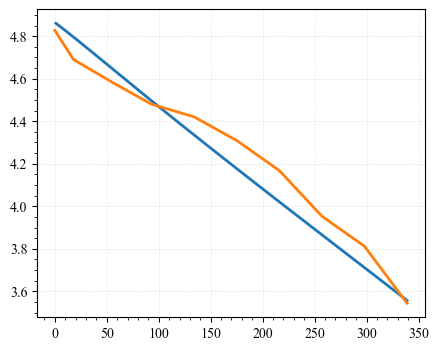

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(range(1,len(Cap)+1),Cap)
ax.plot(dfe["N"],dfe["Capacity [A.h]"])